# NIDS — Data & Intelligence Team Notebook
**Project 7: Network Intrusion Detection System**

This notebook covers the full Week 1–3 workflow:
- Week 1: Data loading, merging, cleaning, feature selection, class balancing, model training
- Week 2: SHAP explainability, multi-class SHAP logic, hyperparameter tuning, model export
- Week 3: Cross-dataset benchmarking, metrics report

---
**Dataset required:** [CIC-IDS-2017](https://www.unb.ca/cic/datasets/ids-2017.html) — download the CSV files and place them in `./data/CIC-IDS-2017/`

**Supplementary (Week 3):** NSL-KDD and UNSW-NB15 CSVs in `./data/NSL-KDD/` and `./data/UNSW-NB15/`

## 0. Install dependencies

---
# Week 1 — Data Pre-processing & Baseline Training

In [1]:
!pip install pandas numpy scikit-learn imbalanced-learn shap matplotlib seaborn joblib
!pip install xgboost==1.7.6
!pip install kagglehub




   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   -------------------------- ------------- 2/3 [kagglehub]
   -------------------------- ------------- 

## 1.1 Imports

In [2]:
import glob
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_curve,
    f1_score, accuracy_score
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import xgboost as xgb
import shap
import joblib

print("All imports OK")
print(f"XGBoost version: {xgb.__version__}")
print(f"SHAP version:    {shap.__version__}")

All imports OK
XGBoost version: 1.7.6
SHAP version:    0.51.0


In [3]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
# file_path = "/Users/ronakkhatwani/Documents/AI_Club_Project/Datasets"

path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
print(path)

# # Load the latest version
# df = kagglehub.load_dataset(
#   KaggleDatasetAdapter.PANDAS,
#   "chethuhn/network-intrusion-dataset",
#   file_path,
#   # Provide any additional arguments like
#   # sql_query or pandas_kwargs. See the
#   # documenation for more information:
#   # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
# )

# print("First 5 records:", df.head())

100%|███████████████████████████████████████████████████████████████████████████████| 230M/230M [01:58<00:00, 2.03MB/s]

Extracting files...


C:\Users\Vidur\.cache\kagglehub\datasets\chethuhn\network-intrusion-dataset\versions\1


## 1.2 Configuration

In [4]:
# ── Paths ──────────────────────────────────────────────────────────────────
CIC_DIR = "./data/CIC-IDS-2017"
NSLKDD_DIR   = "./data/NSL-KDD/"
UNSW_DIR     = "./data/UNSW-NB15/"
OUTPUT_DIR   = "./models/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Reproducibility ────────────────────────────────────────────────────────
RANDOM_STATE = 5

# ── Sampling caps (adjust if RAM is limited) ────────────────────────────────
BENIGN_CAP   = 200_000   # max benign rows before SMOTE
TEST_SIZE    = 0.20

# ── Columns that are identifiers, not features ─────────────────────────────
DROP_COLS = [
    'Flow ID', 'Source IP', 'Source Port',
    'Destination IP', 'Destination Port',
    'Timestamp', 'Label'
]

print("Config set.")

Config set.


## 1.3 Load & merge CIC-IDS-2017 CSVs

In [5]:
all_files = glob.glob(os.path.join(CIC_DIR, "*.csv"))
assert len(all_files) > 0, f"No CSV files found in {CIC_DIR}"
print(f"Found {len(all_files)} CSV file(s): {[os.path.basename(f) for f in all_files]}")

dfs = []
for f in all_files:
    df = pd.read_csv(f, encoding='utf-8', low_memory=False)
    # CIC-IDS-2017 has leading/trailing spaces in column names
    df.columns = df.columns.str.strip()
    dfs.append(df)
    print(f"  Loaded {os.path.basename(f):45s} → {len(df):>8,} rows")

combined = pd.concat(dfs, ignore_index=True)
print(f"\nMerged total: {len(combined):,} rows, {combined.shape[1]} columns")

Found 8 CSV file(s): ['Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX.csv']
  Loaded Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv →  225,745 rows
  Loaded Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv →  286,467 rows
  Loaded Friday-WorkingHours-Morning.pcap_ISCX.csv     →  191,033 rows
  Loaded Monday-WorkingHours.pcap_ISCX.csv             →  529,918 rows
  Loaded Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv →  288,602 rows
  Loaded Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv →  170,366 rows
  Loaded Tuesday-WorkingHours.pcap_ISCX.csv            →  445,909 rows
  Loaded Wednesday-workingHours.pcap_ISCX.csv          →  6

## 1.4 Clean: fix infinities, NaNs, and label inconsistencies

In [6]:
print("Before cleaning:", combined.shape)

# Replace ±inf (common in Flow Bytes/s, Flow Packets/s)
combined.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with any NaN
combined.dropna(inplace=True)
combined.reset_index(drop=True, inplace=True)

# Normalise label strings
combined['Label'] = combined['Label'].str.strip()

print("After cleaning: ", combined.shape)
print("\nClass distribution:")
print(combined['Label'].value_counts().to_string())

Before cleaning: (2830743, 79)
After cleaning:  (2827876, 79)

Class distribution:
Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11


## 1.5 Feature selection (80 network flow features)

In [7]:
# Drop identifier columns; keep only numeric feature columns
drop_present = [c for c in DROP_COLS if c in combined.columns]
feature_cols = [c for c in combined.columns if c not in drop_present]

# Ensure all features are numeric
X_raw = combined[feature_cols].apply(pd.to_numeric, errors='coerce')
X_raw.dropna(axis=1, how='all', inplace=True)  # remove any all-NaN columns
y_raw = combined['Label']

print(f"Features selected: {X_raw.shape[1]}")
print("Feature list:")
for i, col in enumerate(X_raw.columns, 1):
    print(f"  {i:3d}. {col}")

Features selected: 77
Feature list:
    1. Flow Duration
    2. Total Fwd Packets
    3. Total Backward Packets
    4. Total Length of Fwd Packets
    5. Total Length of Bwd Packets
    6. Fwd Packet Length Max
    7. Fwd Packet Length Min
    8. Fwd Packet Length Mean
    9. Fwd Packet Length Std
   10. Bwd Packet Length Max
   11. Bwd Packet Length Min
   12. Bwd Packet Length Mean
   13. Bwd Packet Length Std
   14. Flow Bytes/s
   15. Flow Packets/s
   16. Flow IAT Mean
   17. Flow IAT Std
   18. Flow IAT Max
   19. Flow IAT Min
   20. Fwd IAT Total
   21. Fwd IAT Mean
   22. Fwd IAT Std
   23. Fwd IAT Max
   24. Fwd IAT Min
   25. Bwd IAT Total
   26. Bwd IAT Mean
   27. Bwd IAT Std
   28. Bwd IAT Max
   29. Bwd IAT Min
   30. Fwd PSH Flags
   31. Bwd PSH Flags
   32. Fwd URG Flags
   33. Bwd URG Flags
   34. Fwd Header Length
   35. Bwd Header Length
   36. Fwd Packets/s
   37. Bwd Packets/s
   38. Min Packet Length
   39. Max Packet Length
   40. Packet Length Mean
   41. Packet

## 1.6 Encode labels & train/test split

In [8]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label encoding:")
for name, code in sorted(label_mapping.items(), key=lambda x: x[1]):
    print(f"  {code:2d} → {name}")

X_train, X_tes, y_train, y_tes = train_test_split(
    X_raw, y_encoded,
    test_size=0.6,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tes, y_tes,
    test_size=0.5,
    random_state=0,
    stratify=y_tes
)




print(f"\nTrain set: {len(X_train):,} rows")
print(f"Validation set:  {len(X_val):,} rows")
print(f"Test set:  {len(X_test):,} rows")

Label encoding:
   0 → BENIGN
   1 → Bot
   2 → DDoS
   3 → DoS GoldenEye
   4 → DoS Hulk
   5 → DoS Slowhttptest
   6 → DoS slowloris
   7 → FTP-Patator
   8 → Heartbleed
   9 → Infiltration
  10 → PortScan
  11 → SSH-Patator
  12 → Web Attack � Brute Force
  13 → Web Attack � Sql Injection
  14 → Web Attack � XSS

Train set: 1,131,150 rows
Validation set:  848,363 rows
Test set:  848,363 rows


In [9]:
import pandas as pd

print("Test set class distribution:")
unique, counts = np.unique(y_test, return_counts=True)
for code, count in zip(unique, counts):
    print(f"  {le.inverse_transform([code])[0]}: {count}")

Test set class distribution:
  BENIGN: 681396
  Bot: 587
  DDoS: 38408
  DoS GoldenEye: 3088
  DoS Hulk: 69037
  DoS Slowhttptest: 1649
  DoS slowloris: 1739
  FTP-Patator: 2380
  Heartbleed: 4
  Infiltration: 11
  PortScan: 47641
  SSH-Patator: 1769
  Web Attack � Brute Force: 452
  Web Attack � Sql Injection: 7
  Web Attack � XSS: 195


## 1.7 Handle class imbalance — under-sample benign, then SMOTE minorities

In [10]:
benign_code = label_mapping.get('BENIGN', label_mapping.get('Benign', None))
assert benign_code is not None, "Could not find BENIGN class in label mapping"

# Step 1: cap benign at BENIGN_CAP rows
current_benign = (y_train == benign_code).sum()
cap = min(BENIGN_CAP, current_benign)

under = RandomUnderSampler(
    sampling_strategy={benign_code: cap},
    random_state=RANDOM_STATE
)
X_under, y_under = under.fit_resample(X_train, y_train)
print(f"After under-sampling: {len(X_under):,} rows")

# Step 2: SMOTE — bring minority classes up to at least 1000 samples each
class_counts = pd.Series(y_under).value_counts()
smote_targets = {
    cls: max(count, 3000)
    for cls, count in class_counts.items()
    if count < cap
}

smote = SMOTE(
    sampling_strategy=smote_targets,
    k_neighbors=3,
    random_state=RANDOM_STATE
)
X_train_bal, y_train_bal = smote.fit_resample(X_under, y_under)

print(f"After SMOTE:          {len(X_train_bal):,} rows")
print("\nBalanced class distribution:")
balanced_counts = pd.Series(y_train_bal).value_counts().sort_index()
for code, count in balanced_counts.items():
    name = le.inverse_transform([code])[0]
    print(f"  {code:2d} {name:40s} {count:>8,}")

After under-sampling: 422,622 rows
After SMOTE:          441,073 rows

Balanced class distribution:
   0 BENIGN                                    200,000
   1 Bot                                         3,000
   2 DDoS                                       51,210
   3 DoS GoldenEye                               4,117
   4 DoS Hulk                                   92,050
   5 DoS Slowhttptest                            3,000
   6 DoS slowloris                               3,000
   7 FTP-Patator                                 3,174
   8 Heartbleed                                  3,000
   9 Infiltration                                3,000
  10 PortScan                                   63,522
  11 SSH-Patator                                 3,000
  12 Web Attack � Brute Force                    3,000
  13 Web Attack � Sql Injection                  3,000
  14 Web Attack � XSS                            3,000


In [11]:


print("Cleaning NaN and Infinite values before SMOTE...")
# 1. Replace any Infinity values with NaN
X_under = X_under.replace([np.inf, -np.inf], np.nan)

# 2. Fill all NaNs with the median of their respective columns
X_under = X_under.fillna(X_under.median())

# 3. Now define your SMOTE targets as before
smote_targets = {
    cls: max(count, 3000)
    for cls, count in class_counts.items()
    if count < cap
}

# 4. Initialize and run SMOTE
smote = SMOTE(
    sampling_strategy=smote_targets,
    k_neighbors=3,
    random_state=RANDOM_STATE
)

print("Running SMOTE (this might take a moment)...")
X_train_bal, y_train_bal = smote.fit_resample(X_under, y_under)

print(f"After SMOTE:          {len(X_train_bal):,} rows")

Cleaning NaN and Infinite values before SMOTE...
Running SMOTE (this might take a moment)...
After SMOTE:          441,073 rows


## 1.8 Train XGBoost classifier (baseline)

In [12]:
n_classes = len(le.classes_)

xgb_model = xgb.XGBClassifier(
    n_estimators=50,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=n_classes,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist'
)

print("Cleaning test data to prevent XGBoost C++ crash...")
# 1. Replace any Infinity values with NaN in X_test
X_test = X_test.replace([np.inf, -np.inf], np.nan)
X_val = X_val.replace([np.inf, -np.inf], np.nan)

# 2. Fill the new NaNs with the median from the *training* data
# (Using training median prevents data leakage)
X_test = X_test.fillna(X_under.median())
X_val = X_val.fillna(X_under.median())

print("Training XGBoost...")
# 3. Now run the fit command as normal
xgb_model.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_val, y_val)],
    verbose=10
)
print("Training complete.")



# print("Training XGBoost...")
# xgb_model.fit(
#     X_train_bal, y_train_bal,
#     eval_set=[(X_test, y_test)],
#     verbose=50
# )
# print("Training complete.")

Cleaning test data to prevent XGBoost C++ crash...
Training XGBoost...
[0]	validation_0-mlogloss:2.00915
[10]	validation_0-mlogloss:0.55210
[20]	validation_0-mlogloss:0.20484
[30]	validation_0-mlogloss:0.08202
[40]	validation_0-mlogloss:0.03609
[49]	validation_0-mlogloss:0.01945
Training complete.


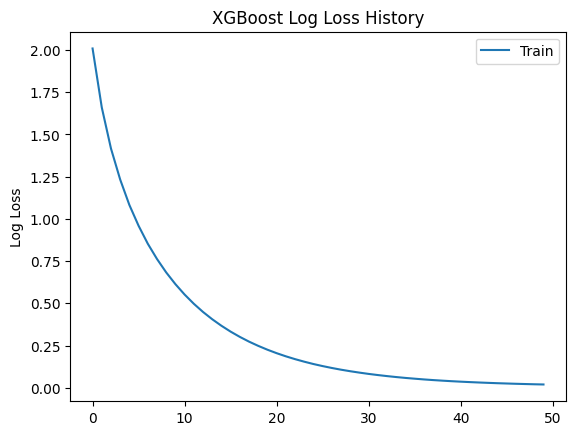

In [13]:
results = xgb_model.evals_result()

epochs = len(results['validation_0']['mlogloss'])
x_axis = range(0, epochs)

fig, ax = plt.subplots()
ax.plot(x_axis, results['validation_0']['mlogloss'], label='Train')
# ax.plot(x_axis, results['validation_1']['mlogloss'], label='Test')
ax.legend()
plt.ylabel('Log Loss')
plt.title('XGBoost Log Loss History')
plt.show()

## 1.9 Train Isolation Forest (anomaly fallback)

In [14]:
# Train ONLY on benign traffic — it learns what "normal" looks like
X_benign = X_train_bal[y_train_bal == benign_code]
X_test_be = X_test[y_test == benign_code]
print(f"Training Isolation Forest on {len(X_benign):,} benign flows...")

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.01,   # expected ~1% anomalies at inference time
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_forest.fit(X_benign)
print("Isolation Forest trained.")

from sklearn.metrics import f1_score
# import numpy as np

# 1. Predict on your test data
# The model returns -1 for outliers and 1 for inliers
y_pred_raw = iso_forest.predict(X_test)

# BUG 2 FIX: binarise y_test before computing F1
# 0 = benign, 1 = any attack class
y_test_binary = np.where(y_test == benign_code, 0, 1)

# Convert Isolation Forest output to binary (−1 → 1 = anomaly, +1 → 0 = normal)
y_pred_binary = np.where(y_pred_raw == -1, 1, 0)

# Calculate F1 Score against binarised ground-truth
f1 = f1_score(y_test_binary, y_pred_binary)

print(f"F1 Score: {f1:.4f}")

Training Isolation Forest on 200,000 benign flows...
Isolation Forest trained.
F1 Score: 0.1533


In [15]:
import shap

print("Building SHAP Permutation Explainer (Bypassing Tree bug)...")

# 1. Provide a small background dataset (e.g., 100 rows) to serve as a baseline.
# Using a small subset of X_train_bal keeps it computationally feasible.
background = shap.maskers.Independent(X_train_bal[:100])

# 2. Pass the prediction function (predict_proba) instead of the model object.
explainer = shap.Explainer(xgb_model.predict_proba, background)

# 3. Calculate SHAP values for a subset of test samples
print("Calculating SHAP values (this takes longer than TreeExplainer)...")
# Note: Permutation is slower, so we strictly limit to 100 samples here.
shap_values = explainer(X_val[:100])

print("\nSuccess! SHAP values calculated.")

Building SHAP Permutation Explainer (Bypassing Tree bug)...
Calculating SHAP values (this takes longer than TreeExplainer)...


PermutationExplainer explainer: 101it [00:21,  3.71it/s]                                                               


Success! SHAP values calculated.


---
# Week 2 — SHAP Explainability & Optimisation

## 2.1 SHAP — build explainer and top-5 feature wrapper

In [16]:
# print("Building SHAP TreeExplainer (this may take a minute)...")
# # Instead of shap.TreeExplainer(xgb_model)
# explainer = shap.Explainer(xgb_model)
# # Note: When using shap.Explainer, you typically call it like this:
# shap_values = explainer(X_test)
# # explainer = shap.TreeExplainer(xyz)


def explain_prediction(row: pd.Series, top_n: int = 5) -> dict:
    """
    Given a single feature row (pd.Series), return:
      - predicted_class: the class name string
      - confidence:      probability of the predicted class
      - top_features:    list of (feature_name, shap_value) for the predicted class
    """
    X_single = row.values.reshape(1, -1)
    X_df     = pd.DataFrame(X_single, columns=X_train_bal.columns)

    # Get class probabilities
    probs          = xgb_model.predict_proba(X_df)[0]
    predicted_code = int(np.argmax(probs))
    predicted_name = le.inverse_transform([predicted_code])[0]
    confidence     = float(probs[predicted_code])

    # SHAP values: shape (1, n_features, n_classes) for multi-class XGBoost
    shap_values = explainer.shap_values(X_df)

    # Select the matrix for the predicted class only
    if isinstance(shap_values, list):
        # Older SHAP: list of arrays, one per class
        class_shap = shap_values[predicted_code][0]
    else:
        # Newer SHAP: single 3-D array (samples, features, classes)
        class_shap = shap_values[0, :, predicted_code]

    # Pick top-N by absolute SHAP value
    feature_names   = list(X_train_bal.columns)
    shap_pairs      = list(zip(feature_names, class_shap))
    top_features    = sorted(shap_pairs, key=lambda x: abs(x[1]), reverse=True)[:top_n]

    return {
        'predicted_class': predicted_name,
        'confidence':      confidence,
        'top_features':    top_features
    }


# Quick smoke test on first test row
sample_row = X_val.iloc[0]
result = explain_prediction(sample_row)
print(f"\nSample prediction: {result['predicted_class']} (confidence: {result['confidence']:.3f})")
print("Top 5 SHAP features:")
for feat, val in result['top_features']:
    print(f"  {feat:40s}  SHAP = {val:+.4f}")


Sample prediction: DoS Hulk (confidence: 0.987)
Top 5 SHAP features:
  Init_Win_bytes_forward                    SHAP = +0.2291
  Bwd Packets/s                             SHAP = +0.1468
  Fwd Header Length                         SHAP = +0.1383
  Fwd Packet Length Min                     SHAP = +0.1056
  Average Packet Size                       SHAP = +0.0785


## 2.2 SHAP summary plot (global feature importance)

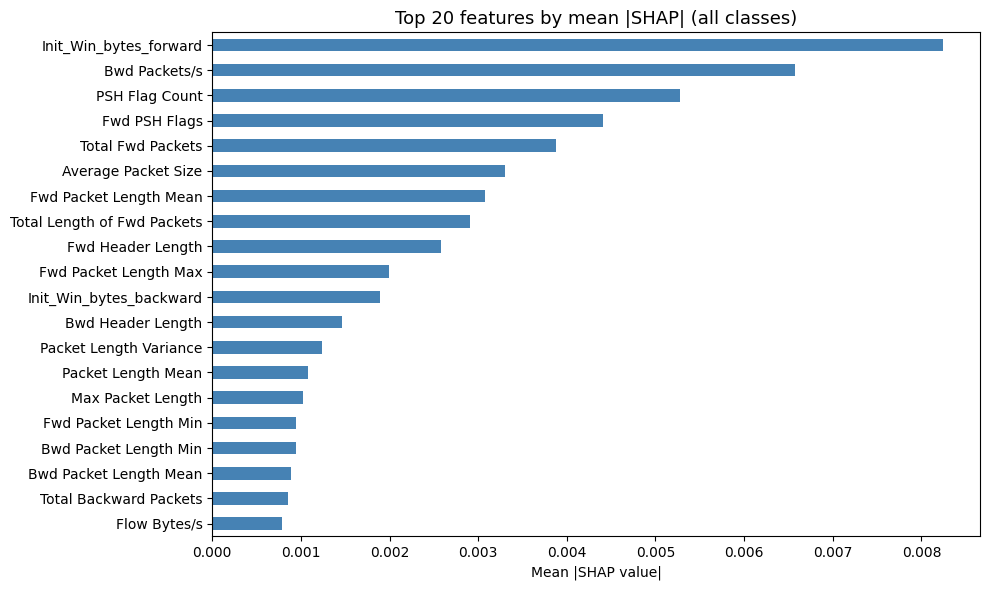

Saved: models/shap_global_importance.png


In [17]:
# Use a sample of the test set for speed
shap_sample = X_val.sample(min(10, len(X_val)), random_state=RANDOM_STATE)
shap_vals   = explainer.shap_values(shap_sample)

# For multi-class, sum |SHAP| across classes to get global importance
if isinstance(shap_vals, list):
    mean_abs = np.mean([np.abs(sv) for sv in shap_vals], axis=0)
else:
    mean_abs = np.mean(np.abs(shap_vals), axis=2)  # (samples, features)

global_importance = pd.Series(
    mean_abs.mean(axis=0),
    index=shap_sample.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
global_importance.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Top 20 features by mean |SHAP| (all classes)', fontsize=13)
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'shap_global_importance.png'), dpi=150)
plt.show()
print("Saved: models/shap_global_importance.png")

## 2.3 Hyperparameter tuning with RandomizedSearchCV

In [18]:
param_dist = {
    'n_estimators':      [200, 300, 500],
    'max_depth':         [6, 8, 10, 12],
    'learning_rate':     [0.05, 0.1, 0.2],
    'subsample':         [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':  [0.6, 0.7, 0.8, 1.0],
    'min_child_weight':  [1, 3, 5],
    'gamma':             [0, 0.1, 0.3],
}

base_xgb = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=n_classes,
    eval_metric='mlogloss',
    use_label_encoder=False,
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_dist,
    n_iter=1,             # increase to 50+ for a thorough search
    scoring='f1_weighted',
    cv=3,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=1               # XGBoost already parallelises internally
)

print("Running RandomizedSearchCV (20 iterations × 3 folds)...")
search.fit(X_train_bal, y_train_bal)

print(f"\nBest params:  {search.best_params_}")
print(f"Best CV F1:   {search.best_score_:.4f}")

best_model = search.best_estimator_

Running RandomizedSearchCV (20 iterations × 3 folds)...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.2, max_depth=6, min_child_weight=5, n_estimators=500, subsample=1.0; total time= 2.4min
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.2, max_depth=6, min_child_weight=5, n_estimators=500, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.2, max_depth=6, min_child_weight=5, n_estimators=500, subsample=1.0; total time=  54.7s

Best params:  {'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.8}
Best CV F1:   nan


## 2.4 Evaluate best model on held-out test set

In [19]:
y_pred = best_model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
f1     = f1_score(y_test, y_pred, average='weighted')

print(f"Test accuracy:      {acc:.4f}  (target: >0.98)")
print(f"Weighted F1 score:  {f1:.4f}")
print("\nPer-class report:")
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_,
    digits=4
))

Test accuracy:      0.9986  (target: >0.98)
Weighted F1 score:  0.9986

Per-class report:
                            precision    recall  f1-score   support

                    BENIGN     0.9999    0.9987    0.9993    681396
                       Bot     0.6454    0.9642    0.7732       587
                      DDoS     0.9992    0.9998    0.9995     38408
             DoS GoldenEye     0.9968    0.9955    0.9961      3088
                  DoS Hulk     0.9982    0.9997    0.9990     69037
          DoS Slowhttptest     0.9406    0.9885    0.9639      1649
             DoS slowloris     0.9903    0.9965    0.9934      1739
               FTP-Patator     0.9966    0.9992    0.9979      2380
                Heartbleed     0.8000    1.0000    0.8889         4
              Infiltration     1.0000    0.9091    0.9524        11
                  PortScan     0.9944    0.9997    0.9970     47641
               SSH-Patator     0.9994    0.9983    0.9989      1769
  Web Attack � Brute Forc

In [20]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Make predictions on your test set
# y_pred = xgb_model.predict(X_test)

# 2. Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Overall Accuracy: {accuracy * 100:.2f}%")

# 3. (Optional) Detailed breakdown by class
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Overall Accuracy: 99.86%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    681396
           1       0.65      0.96      0.77       587
           2       1.00      1.00      1.00     38408
           3       1.00      1.00      1.00      3088
           4       1.00      1.00      1.00     69037
           5       0.94      0.99      0.96      1649
           6       0.99      1.00      0.99      1739
           7       1.00      1.00      1.00      2380
           8       0.80      1.00      0.89         4
           9       1.00      0.91      0.95        11
          10       0.99      1.00      1.00     47641
          11       1.00      1.00      1.00      1769
          12       0.73      0.69      0.71       452
          13       0.42      0.71      0.53         7
          14       0.42      0.54      0.47       195

    accuracy                           1.00    848363
   macro avg       0.86      0.

## 2.5 Confusion matrix

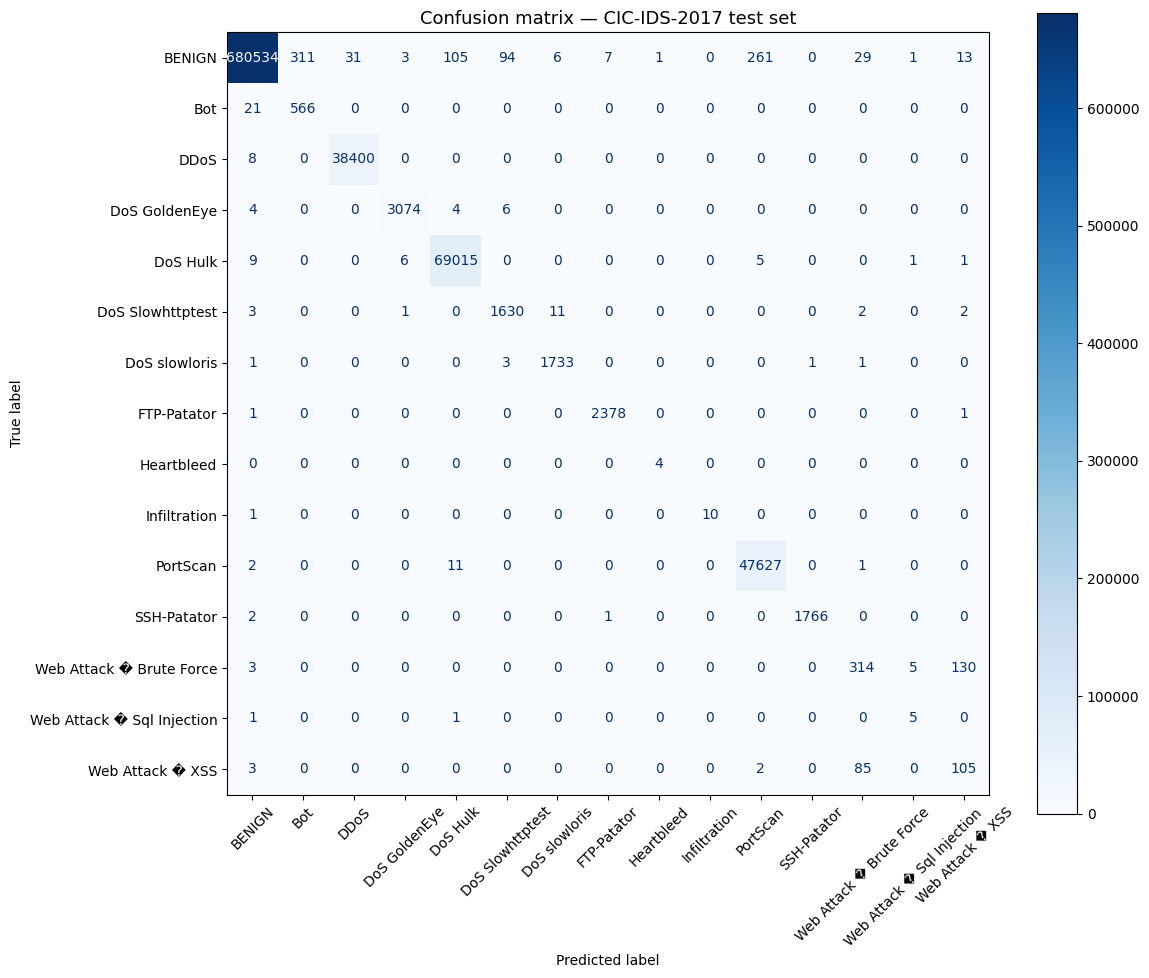

Saved: models/confusion_matrix_cic.png


In [21]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap='Blues')
ax.set_title('Confusion matrix — CIC-IDS-2017 test set', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix_cic.png'), dpi=150)
plt.show()
print("Saved: models/confusion_matrix_cic.png")

## 2.6 False positive rate on benign traffic

In [22]:
benign_mask  = (y_test == benign_code)
benign_true  = benign_mask.sum()
# False positives = benign flows predicted as any attack
false_pos    = ((benign_mask) & (y_pred != benign_code)).sum()
fpr          = false_pos / benign_true

print(f"Benign flows in test set:   {benign_true:,}")
print(f"Misclassified as attack:    {false_pos:,}")
print(f"False positive rate (FPR):  {fpr:.4f}  (target: <0.01)")

if fpr < 0.01:
    print("  Target MET")
else:
    print("  Target NOT met — consider raising confidence threshold for benign class")

Benign flows in test set:   681,396
Misclassified as attack:    862
False positive rate (FPR):  0.0013  (target: <0.01)
  Target MET


## 2.7 Export models for Engineering team

In [24]:
import os
import json
import joblib

# Create directory if it doesn't exist
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 1. Save XGBoost (The .joblib file is what our API uses)
joblib.dump(best_model, os.path.join(OUTPUT_DIR, 'xgb_nids.joblib'), compress=3)

# 2. DISABLED for Python 3.14 compatibility:
# best_model.save_model(os.path.join(OUTPUT_DIR, 'xgb_nids.json'))

# 3. Save Isolation Forest
joblib.dump(iso_forest, os.path.join(OUTPUT_DIR, 'iso_forest.joblib'), compress=3)

# 4. Save label encoder
joblib.dump(le, os.path.join(OUTPUT_DIR, 'label_encoder.joblib'))

# 5. Save feature column order
feature_list = list(X_train_bal.columns)
with open(os.path.join(OUTPUT_DIR, 'feature_columns.json'), 'w') as fh:
    json.dump(feature_list, fh, indent=2)

# 6. Save a sample flow
sample_flow = X_test.iloc[0].to_dict()
with open(os.path.join(OUTPUT_DIR, 'sample_flow.json'), 'w') as fh:
    json.dump(sample_flow, fh, indent=2)

print("Exported:")
for fname in os.listdir(OUTPUT_DIR):
    fpath = os.path.join(OUTPUT_DIR, fname)
    size  = os.path.getsize(fpath) / 1024
    print(f"  {fname:35s}  {size:8.1f} KB")

Exported:
  confusion_matrix_cic.png                173.5 KB
  feature_columns.json                      1.7 KB
  iso_forest.joblib                       353.6 KB
  label_encoder.joblib                      0.7 KB
  sample_flow.json                          2.2 KB
  shap_global_importance.png               87.5 KB
  xgb_nids.joblib                        2216.8 KB


---
# Week 3 — Validation & Benchmarking

## 3.1 Helper: evaluate model on an external dataset

In [25]:
def benchmark_on_dataset(csv_path: str, label_col: str, dataset_name: str):
    """
    Load an external benchmark CSV, align its columns to the trained
    feature set, run inference, and print a metrics summary.
    """
    print(f"\n{'='*60}")
    print(f"Benchmarking on: {dataset_name}")
    print(f"{'='*60}")

    df = pd.read_csv(csv_path, low_memory=False)
    df.columns = df.columns.str.strip()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    if label_col not in df.columns:
        print(f"  Label column '{label_col}' not found. Columns: {list(df.columns[:10])}")
        return

    y_bench = df[label_col].astype(str).str.strip()

    # Keep only columns the model was trained on; fill missing with 0
    X_bench = pd.DataFrame(index=df.index, columns=feature_list, dtype=float)
    for col in feature_list:
        if col in df.columns:
            X_bench[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        else:
            X_bench[col] = 0.0   # feature not present in this dataset

    # Binary: 1 = attack, 0 = normal
    y_binary_true = (y_bench.str.lower() != 'normal') & \
                    (y_bench.str.lower() != 'benign') & \
                    (y_bench != '0')
    y_binary_true = y_binary_true.astype(int)

    preds        = best_model.predict(X_bench)
    y_binary_pred = (preds != benign_code).astype(int)

    acc = accuracy_score(y_binary_true, y_binary_pred)
    f1  = f1_score(y_binary_true, y_binary_pred, average='weighted')
    print(f"  Rows evaluated:   {len(X_bench):,}")
    print(f"  Binary accuracy:  {acc:.4f}")
    print(f"  Weighted F1:      {f1:.4f}")
    print(classification_report(y_binary_true, y_binary_pred,
                                 target_names=['Normal', 'Attack'], digits=4))

    # Confusion matrix
    cm = confusion_matrix(y_binary_true, y_binary_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Attack']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f'Confusion matrix — {dataset_name}', fontsize=11)
    plt.tight_layout()
    safe_name = dataset_name.replace(' ', '_').replace('/', '-')
    plt.savefig(os.path.join(OUTPUT_DIR, f'cm_{safe_name}.png'), dpi=150)
    plt.show()

print("Benchmark helper defined.")

Benchmark helper defined.


## 3.2 Benchmark: NSL-KDD

In [26]:
nslkdd_test_path = os.path.join(NSLKDD_DIR, 'KDDTest+.csv')

if os.path.exists(nslkdd_test_path):
    # NSL-KDD uses 'label' or 'class' as its label column
    benchmark_on_dataset(nslkdd_test_path, label_col='label', dataset_name='NSL-KDD')
else:
    print(f"NSL-KDD file not found at {nslkdd_test_path}")
    print("Download KDDTest+.csv from https://www.unb.ca/cic/datasets/nsl.html")

NSL-KDD file not found at ./data/NSL-KDD/KDDTest+.csv
Download KDDTest+.csv from https://www.unb.ca/cic/datasets/nsl.html


## 3.3 Benchmark: UNSW-NB15

In [27]:
unsw_test_path = os.path.join(UNSW_DIR, 'UNSW_NB15_testing-set.csv')

if os.path.exists(unsw_test_path):
    # UNSW-NB15 uses 'label' (0 = normal, 1 = attack) or 'attack_cat'
    benchmark_on_dataset(unsw_test_path, label_col='label', dataset_name='UNSW-NB15')
else:
    print(f"UNSW-NB15 file not found at {unsw_test_path}")
    print("Download from https://research.unsw.edu.au/projects/unsw-nb15-dataset")

UNSW-NB15 file not found at ./data/UNSW-NB15/UNSW_NB15_testing-set.csv
Download from https://research.unsw.edu.au/projects/unsw-nb15-dataset


## 3.4 Precision–Recall curves (CIC-IDS-2017 test set)

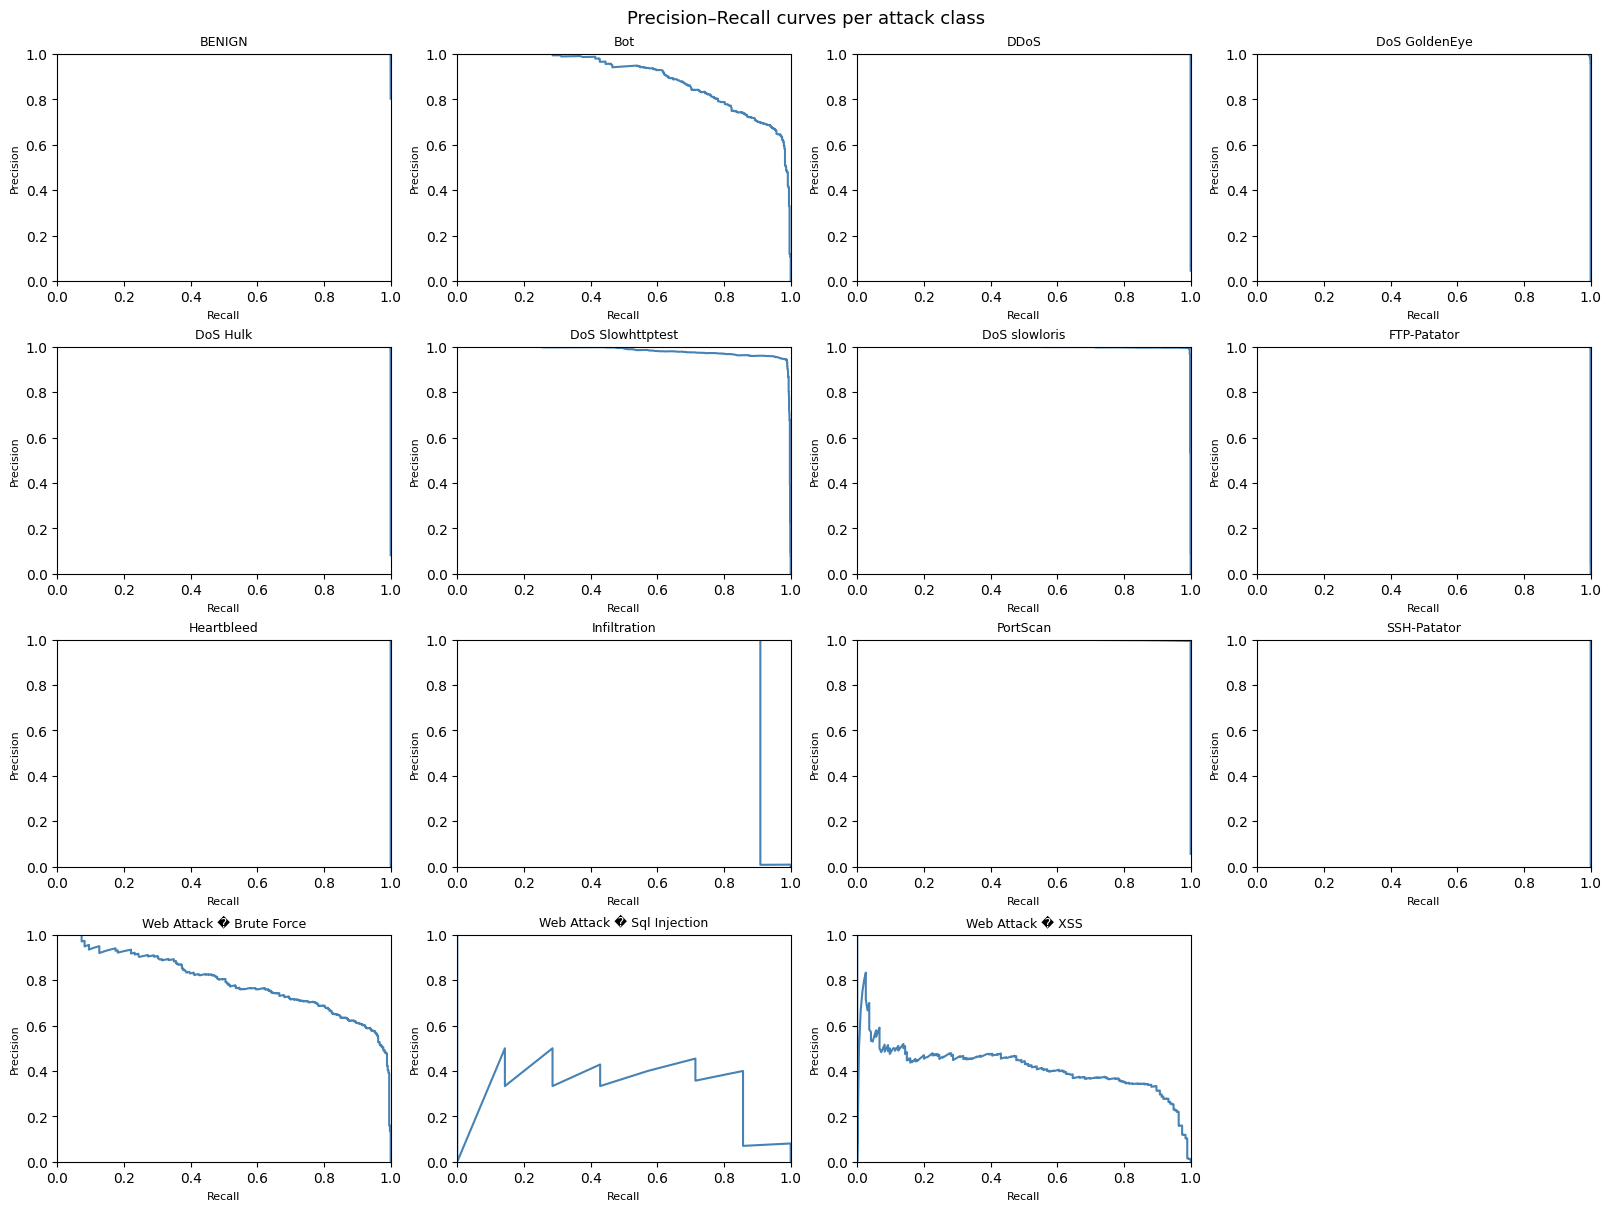

Saved: models/precision_recall_curves.png


In [28]:
y_prob = best_model.predict_proba(X_test)

fig, axes = plt.subplots(
    nrows=4, ncols=4,
    figsize=(16, 12),
    constrained_layout=True
)
axes = axes.flatten()

for i, class_name in enumerate(le.classes_):
    if i >= len(axes):
        break
    y_bin  = (y_test == i).astype(int)
    prec, rec, _ = precision_recall_curve(y_bin, y_prob[:, i])
    axes[i].plot(rec, prec, lw=1.5, color='steelblue')
    axes[i].set_title(class_name, fontsize=9)
    axes[i].set_xlabel('Recall', fontsize=8)
    axes[i].set_ylabel('Precision', fontsize=8)
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Precision–Recall curves per attack class', fontsize=13)
plt.savefig(os.path.join(OUTPUT_DIR, 'precision_recall_curves.png'), dpi=150)
plt.show()
print("Saved: models/precision_recall_curves.png")

## 3.5 Inference demo — single flow with anomaly fallback

In [30]:
CONFIDENCE_THRESHOLD = 0.60  # flows below this go to Isolation Forest


def classify_flow(flow_features: pd.Series) -> dict:
    """
    Full inference pipeline for a single network flow:
      1. Run XGBoost
      2. If confidence < threshold → run Isolation Forest as fallback
      3. Return classification, confidence, top SHAP features, recommended action
    """
    X = pd.DataFrame([flow_features], columns=feature_list)

    probs      = best_model.predict_proba(X)[0]
    pred_code  = int(np.argmax(probs))
    pred_name  = le.inverse_transform([pred_code])[0]
    confidence = float(probs[pred_code])

    if confidence < CONFIDENCE_THRESHOLD:
        # Fallback: Isolation Forest
        iso_pred = iso_forest.predict(X)[0]  # +1 = normal, -1 = anomaly
        if iso_pred == -1:
            pred_name  = 'UNKNOWN_ANOMALY'
            confidence = None

    # SHAP for explainability (skip for UNKNOWN_ANOMALY)
    top_features = []
    if pred_name != 'UNKNOWN_ANOMALY':
        expl = explain_prediction(flow_features)
        top_features = expl['top_features']

    # Map to recommended response action
    action_map = {
        'BENIGN':             'allow',
        'DDoS':               'block_source_ip',
        'PortScan':           'rate_limit_and_alert',
        'Bot':                'isolate_host',
        'Infiltration':       'escalate_immediately',
        'UNKNOWN_ANOMALY':    'alert_soc_for_review',
    }
    action = action_map.get(pred_name, 'alert_and_log')

    return {
        'classification': pred_name,
        'confidence':     confidence,
        'top_features':   top_features,
        'action':         action,
    }


# Demo: run on 3 random test flows
for idx in range(3):
    sample = X_test.iloc[idx]
    result = classify_flow(sample)
    true_label = le.inverse_transform([y_test[idx]])[0]
    print(f"\n--- Flow {idx} ---")
    print(f"  True label:     {true_label}")
    print(f"  Predicted:      {result['classification']}")
    conf_str = f"{result['confidence']:.3f}" if result['confidence'] else 'N/A'
    print(f"  Confidence:     {conf_str}")
    print(f"  Action:         {result['action']}")
    if result['top_features']:
        print("  Top SHAP features:")
        for feat, val in result['top_features']:
            print(f"    {feat:38s}  {val:+.4f}")


--- Flow 0 ---
  True label:     BENIGN
  Predicted:      BENIGN
  Confidence:     1.000
  Action:         allow
  Top SHAP features:
    Init_Win_bytes_backward                 +0.0110
    Fwd Header Length                       -0.0042
    Bwd Packet Length Min                   +0.0034
    Average Packet Size                     -0.0031
    Fwd IAT Total                           -0.0024

--- Flow 1 ---
  True label:     BENIGN
  Predicted:      BENIGN
  Confidence:     1.000
  Action:         allow
  Top SHAP features:
    Average Packet Size                     -0.0045
    Packet Length Mean                      +0.0034
    Max Packet Length                       -0.0033
    Bwd Packets/s                           +0.0029
    Bwd Header Length                       +0.0028

--- Flow 2 ---
  True label:     BENIGN
  Predicted:      BENIGN
  Confidence:     1.000
  Action:         allow
  Top SHAP features:
    Total Fwd Packets                       -0.0169
    Max Packet Length  

In [33]:
import json
import os

# Find a row that actually has data (where the sum of features is not 0)
# We'll look for a row where 'Total Fwd Packets' or 'Flow Duration' is > 0
rich_sample = X_test[X_test['Total Fwd Packets'] > 0].iloc[0].to_dict()

# Save it again to the models folder
with open(os.path.join(OUTPUT_DIR, 'sample_flow.json'), 'w') as fh:
    json.dump(rich_sample, fh, indent=2)

print("New rich sample saved! Go back to the Dashboard and click Load Sample again.")

New rich sample saved! Go back to the Dashboard and click Load Sample again.


In [34]:
import json
import os

# The data you provided
sample_data = {
    "Flow Duration": 3350625.0, "Total Fwd Packets": 5.0, "Total Backward Packets": 1.0,
    "Total Length of Fwd Packets": 123.0, "Total Length of Bwd Packets": 46.0,
    "Fwd Packet Length Max": 46.0, "Fwd Packet Length Min": 0.0, 
    "Fwd Packet Length Mean": 24.6, "Fwd Packet Length Std": 23.27659769,
    "Bwd Packet Length Max": 46.0, "Bwd Packet Length Min": 46.0,
    "Bwd Packet Length Mean": 46.0, "Bwd Packet Length Std": 0.0,
    "Flow Bytes/s": 50.43835105, "Flow Packets/s": 1.790710688,
    "Flow IAT Mean": 670125.0, "Flow IAT Std": 1475831.137, "Flow IAT Max": 3310031.0,
    "Flow IAT Min": 23.0, "Fwd IAT Total": 3350625.0, "Fwd IAT Mean": 837656.25,
    "Fwd IAT Std": 1648330.211, "Fwd IAT Max": 3310031.0, "Fwd IAT Min": 49.0,
    "Bwd IAT Total": 0.0, "Bwd IAT Mean": 0.0, "Bwd IAT Std": 0.0,
    "Bwd IAT Max": 0.0, "Bwd IAT Min": 0.0, "Fwd PSH Flags": 1.0,
    "Bwd PSH Flags": 0.0, "Fwd URG Flags": 0.0, "Bwd URG Flags": 0.0,
    "Fwd Header Length": 160.0, "Bwd Header Length": 32.0, "Fwd Packets/s": 1.492258907,
    "Bwd Packets/s": 0.298451781, "Min Packet Length": 0.0, "Max Packet Length": 46.0,
    "Packet Length Mean": 30.71428571, "Packet Length Std": 21.68497395,
    "Packet Length Variance": 470.2380952, "FIN Flag Count": 0.0, "SYN Flag Count": 1.0,
    "RST Flag Count": 0.0, "PSH Flag Count": 0.0, "ACK Flag Count": 1.0,
    "URG Flag Count": 0.0, "CWE Flag Count": 0.0, "ECE Flag Count": 0.0,
    "Down/Up Ratio": 0.0, "Average Packet Size": 35.83333333, "Avg Fwd Segment Size": 24.6,
    "Avg Bwd Segment Size": 46.0, "Fwd Header Length.1": 160.0, "Fwd Avg Bytes/Bulk": 0.0,
    "Fwd Avg Packets/Bulk": 0.0, "Fwd Avg Bulk Rate": 0.0, "Bwd Avg Bytes/Bulk": 0.0,
    "Bwd Avg Packets/Bulk": 0.0, "Bwd Avg Bulk Rate": 0.0, "Subflow Fwd Packets": 5.0,
    "Subflow Fwd Bytes": 123.0, "Subflow Bwd Packets": 1.0, "Subflow Bwd Bytes": 46.0,
    "Init_Win_bytes_forward": 338.0, "Init_Win_bytes_backward": 370.0,
    "act_data_pkt_fwd": 2.0, "min_seg_size_forward": 32.0, "Active Mean": 0.0,
    "Active Std": 0.0, "Active Max": 0.0, "Active Min": 0.0, "Idle Mean": 0.0,
    "Idle Std": 0.0, "Idle Max": 0.0, "Idle Min": 0.0
}

# IMPORTANT: Wrap the data in "payload"
wrapped_sample = {"payload": sample_data}

# Save it to the models folder
with open('models/sample_flow.json', 'w') as f:
    json.dump(wrapped_sample, f, indent=2)

print("Sample fixed! Refresh the dashboard and click Load Sample.")

Sample fixed! Refresh the dashboard and click Load Sample.


---
## Summary of outputs

All files are saved to `./models/`:

| File | Description |
|---|---|
| `xgb_nids.joblib` | Trained XGBoost model (Python) |
| `xgb_nids.json` | Trained XGBoost model (language-agnostic) |
| `iso_forest.joblib` | Isolation Forest anomaly fallback |
| `label_encoder.joblib` | Label encoder (int → class name) |
| `feature_columns.json` | Ordered feature list for correct inference |
| `shap_global_importance.png` | Top 20 features by mean \|SHAP\| |
| `confusion_matrix_cic.png` | Confusion matrix on CIC-IDS-2017 test set |
| `precision_recall_curves.png` | Per-class precision–recall curves |

**Hand these files to the Engineering team** — they need `xgb_nids.json`, `label_encoder.joblib`, and `feature_columns.json` to wire up the FastAPI endpoint.